# Introdução
Nesse trabalho é feito um classificador de dados 3D, em que há coleção de objetos de 5 categorias diferentes: aviões, cadeiras, sofás, mesas e camas. Foi estudado a abordagem fazendo uso de uma representação dos dados por malha e representação de dados por grafo, sendo que malha foi escolhida para ser usada no final. Durante o processo de obtenção das nuvens de pontos, é aplicado métodos de *data augumentation* para ampliar a base de dados. Por fim, com os dados pegos, aumetado a base e montado a repesentação em malha, é feito dois treinamentos de modelos, um de RNN e outro de SVM, com características extraídas da malha. Ao fim do trabalho, é possível ter uma comparação entre os dois modelos para a classificação de dados, além de uma comparação entre as vantagens e desvantagens do uso de malha e de grafos para representação dos dados.

# Materiais
Para obtenção dos dados, foi usado o Kaagle, em que foi pego uma base de dados do Modelnet40 através dele. A base de dados possuí diversos tipos de objetos representados por nuvens de pontos, mas foi optado só usar 5 categorias.

#Analise da implementação
## Malha vs Grafo
No inicio ouve uma tentativa de usar grafo, através do uso do algoritmo de KNN. Entretanto, o uso de grafo acabou de encontro com questões de complexidade para extração de características e do processo de treinamento. O grafo consegue entregar uma representação muito mais complexa do objeto 3D, mas começou a me exigir mais no que diz respeito a parte de realizar o processo de classificação. Para técnicas de deeplearning, em que o próprio modelo irá fazer o processo de extração de características, ele parece ser mais adequado.

Já usando malhas, o processo de extração foi mais simples, principalmente por conta do uso de convex hull. Através da malha foi possível extraír mais facilmente dados para passar em algoritmos de classificação mais simples. Foi possível extraír dados como área, volume e corvatura, além de outros dados usando esse como base e fazendo relações entre os pontos da nuvem de pontos e os vértices da malha. Em contra partida, alguns detalhes acabam sendo perdidos no uso da malha, principalmente se tratando do convexhull, o qual não monta uma malha perfeita do objeto, mas sim cria um ínvolucro em torno da nuvem de pontos com o menor poliedro convexo possível.

Essa maior abstração que é realizado na representação de mesh usando convexhull trás alguns impactos no próprio processo de classificação. Em ambos os modelos de classificação utilizados, avião foi o dado que alcançou maior nível de acurácia. Ao observar os resultados da representação em malha dele, é possível notar algo, que é o fato que entre os 5 objetos classificados, a malha dele é a qual mais se distingui dos outros. Se objetos como cadeira, sofa, cama e mesa tendem a gerar uma figura mais quadricular ou um paralelepipedo, o avião sai dessa tendência, com formatos mais próximos de um romboedro. Isso mostra que para objetos que gerem malhas com estruturas parecidas, talvez soluções de representação em malha podem não ser as mais interessantes para a questão de classificação, ainda mais se for uma malha mais simples, como a do convexHull.
## Resultados das classificações
Para as classificações, foram usadas soluções com SVM e RNN. Os resultados obtidos por ambos foi bem emparelhado, com ambos conseguindo bons resultados em termos de acuracia geral e caindo nos mesmos problemas que foi abordado em relação a objetos com formatos parecidos. Isso é interessante, pois mostra que, apesar de uma tendência que há para o uso de RNN, soluções mais simples e menos custosas como SVM ainda possuem cenários em que podem ser aplicadas e obter resultados excelentes. Mas em um cenário em que as características obtidas via algoritmo não se mostrem o suficiente para conseguir um bom nível de acurácia, soluções como SVM que dependem de um processo posterior de extração de características podem ficar menos interessantes, assim dando mais espaço as soluções de redes neurais e deeplearning, o qual podem ter camadas que realizam esse processo.

In [ ]:
!pip install open3d scikit-learn matplotlib

In [ ]:
!pip install trimesh

  Using cached trimesh-4.11.5-py3-none-any.whl.metadata (13 kB)
Using cached trimesh-4.11.5-py3-none-any.whl (740 kB)


In [ ]:
import open3d as o3d
import kagglehub
import os
import glob
import numpy as np
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import ConvexHull
import trimesh
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import laplacian
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random



In [ ]:
path_dataset = kagglehub.dataset_download("balraj98/modelnet40-princeton-3d-object-dataset")

print("Caminho dos arquivos baixados:", path_dataset)

100%|██████████| 1.91G/1.91G [00:26<00:00, 76.1MB/s]

Extracting files...


Caminho dos arquivos baixados: /root/.cache/kagglehub/datasets/balraj98/modelnet40-princeton-3d-object-dataset/versions/1


In [ ]:
def fix_off_header(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    if lines[0].startswith('OFF') and lines[0].strip() != 'OFF':
        lines[0] = lines[0].replace('OFF', 'OFF\n', 1)
        with open(file_path, 'w') as f:
            f.writelines(lines)

In [ ]:
def get_rotated(input_points):
    points = input_points.copy()
    theta = np.random.uniform(0, 2 * np.pi)
    rotation_matrix = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    return np.dot(points, rotation_matrix)

def get_noisy(input_points, sigma=0.01):
    points = input_points.copy()
    noise = np.random.normal(0, sigma, size=points.shape)
    return points + noise

def get_scaled(input_points):
    points = input_points.copy()
    scales = np.random.uniform(0.8, 1.2, size=(1, 3))
    return points * scales

In [ ]:
def load_with_open3d(base_path, categories, num_points):
    dataPoints, dataHull, labels = [], [], []

    for idx, cat in enumerate(categories):
        files = glob.glob(os.path.join(base_path, "ModelNet40", cat, "train/*.off"))
        print(f"Processando {cat}...")

        for f in files:
            try:
                fix_off_header(f)
                mesh = o3d.io.read_triangle_mesh(f)
                pcd = mesh.sample_points_uniformly(number_of_points=num_points)

                points = np.asarray(pcd.points)
                points -= np.mean(points, axis=0)
                scale = np.max(np.linalg.norm(points, axis=1))
                if scale > 0:
                    points /= scale

                rotatedPoints = get_rotated(points)
                noisyPoints = get_noisy(points)
                scaledPoints = get_scaled(points)

                hull = ConvexHull(points)

                noisyhull = ConvexHull(noisyPoints)

                scaledhull = ConvexHull(scaledPoints)

                rotatedhull = ConvexHull(rotatedPoints)

                dataHull.append(hull)
                dataPoints.append(points)
                labels.append(idx)

                dataHull.append(rotatedhull)
                dataPoints.append(rotatedPoints)
                labels.append(idx)

                dataHull.append(noisyhull )
                dataPoints.append(noisyPoints)
                labels.append(idx)

                dataHull.append(scaledhull )
                dataPoints.append(scaledPoints)
                labels.append(idx)
            except Exception:
                continue

    return np.array(dataPoints), np.array(labels), np.array(dataHull)

In [ ]:
minhas_categorias = ['airplane', 'chair', 'table', 'bed', 'sofa']

X, y, z = load_with_open3d(path_dataset, minhas_categorias, num_points=2000)

print(f"\nSucesso!")
print(f"Shape dos dados: {X.shape}")
print(f"Shape dos labels: {y.shape}")
print(f"Shape dos dados hull: {z.shape}")
for i, categoria in enumerate(minhas_categorias):
    quantidade = np.sum(y == i)
    print(f"Categoria: {categoria:<10} | Total de nuvens de pontos: {quantidade}")

Processando airplane...
Processando chair...
Processando table...
Processando bed...
Processando sofa...

Sucesso!
Shape dos dados: (12408, 2000, 3)
Shape dos labels: (12408,)
Shape dos dados hull: (12408,)
Categoria: airplane   | Total de nuvens de pontos: 2504
Categoria: chair      | Total de nuvens de pontos: 3556
Categoria: table      | Total de nuvens de pontos: 1568
Categoria: bed        | Total de nuvens de pontos: 2060
Categoria: sofa       | Total de nuvens de pontos: 2720


In [ ]:
def plotFigs(points, hull, elev = 90, azim = 270):
  fig = plt.figure(figsize=(14, 6))

  ax1 = fig.add_subplot(121, projection='3d')
  ax1.scatter(points[:,0], points[:,1], points[:,2], s=5)
  ax1.set_title("Nuvem de Pontos 3D")
  ax1.view_init(elev=elev, azim=azim)

  ax2 = fig.add_subplot(122, projection='3d')
  ax2.scatter(points[:,0], points[:,1], points[:,2], s=2)
  for simplex in hull.simplices:
    simplex = np.append(simplex, simplex[0])
    ax2.plot(points[simplex,0], points[simplex,1], points[simplex,2])

  ax2.set_title("Grafo Hull")
  ax2.view_init(elev=elev, azim=azim)

  plt.tight_layout()
  plt.show()

sofa


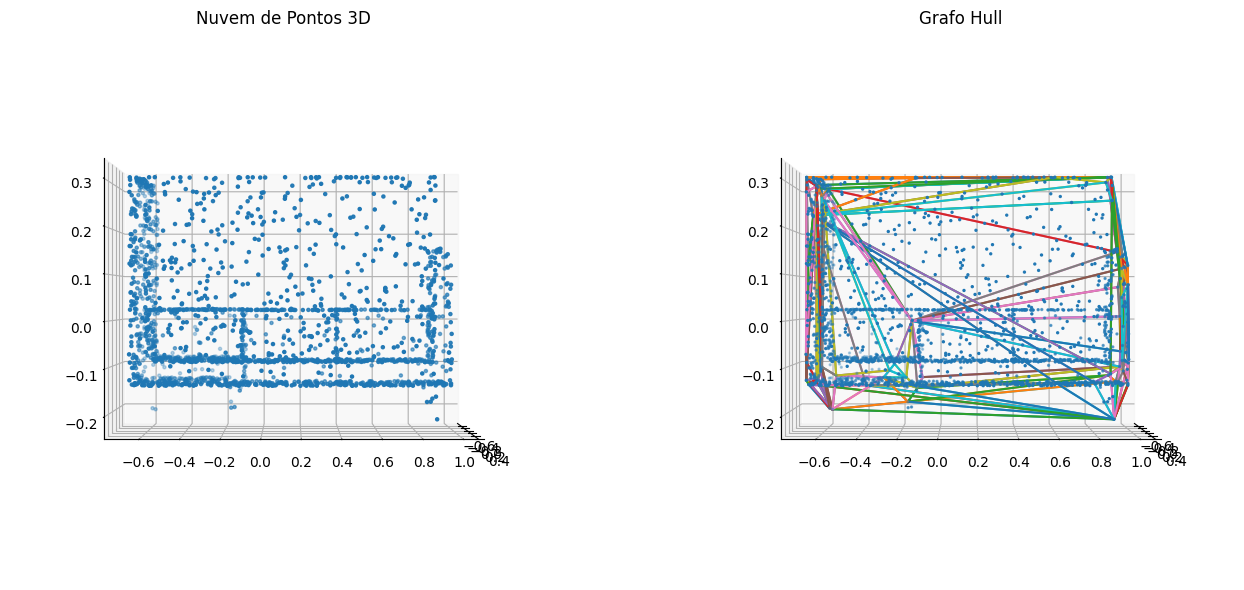

airplane


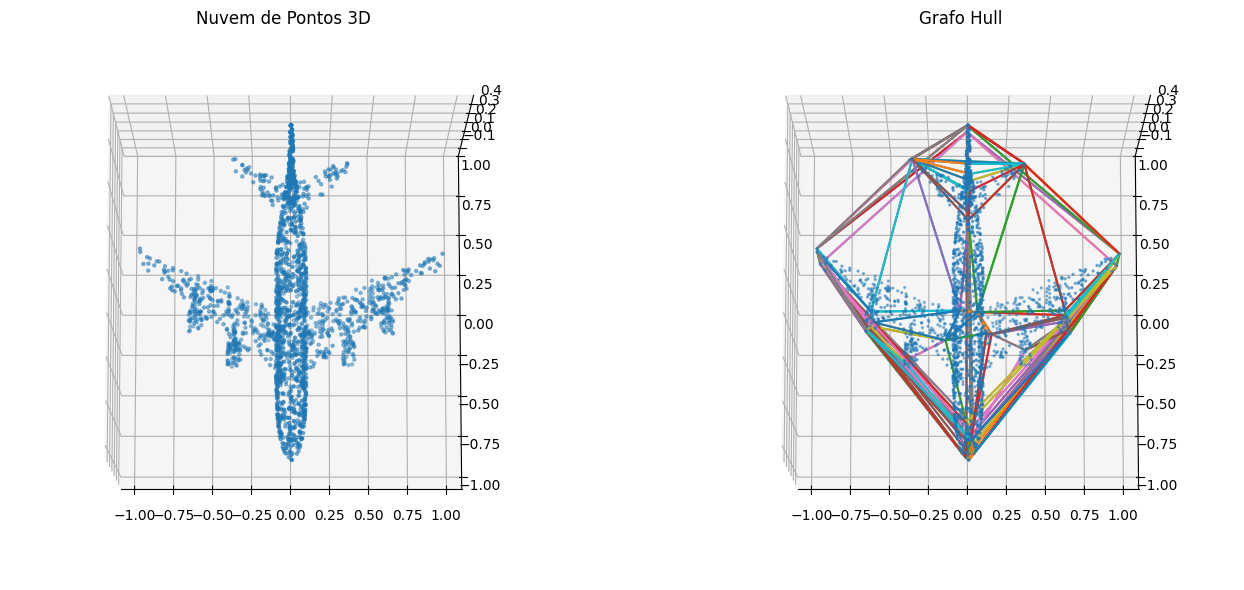

chair


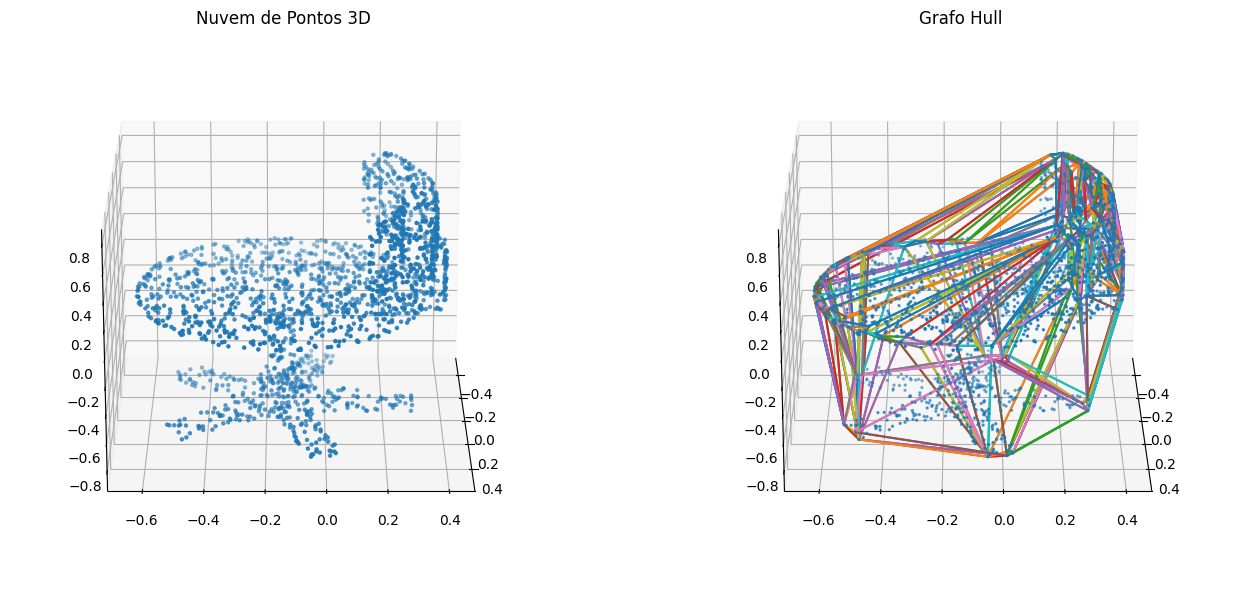

table


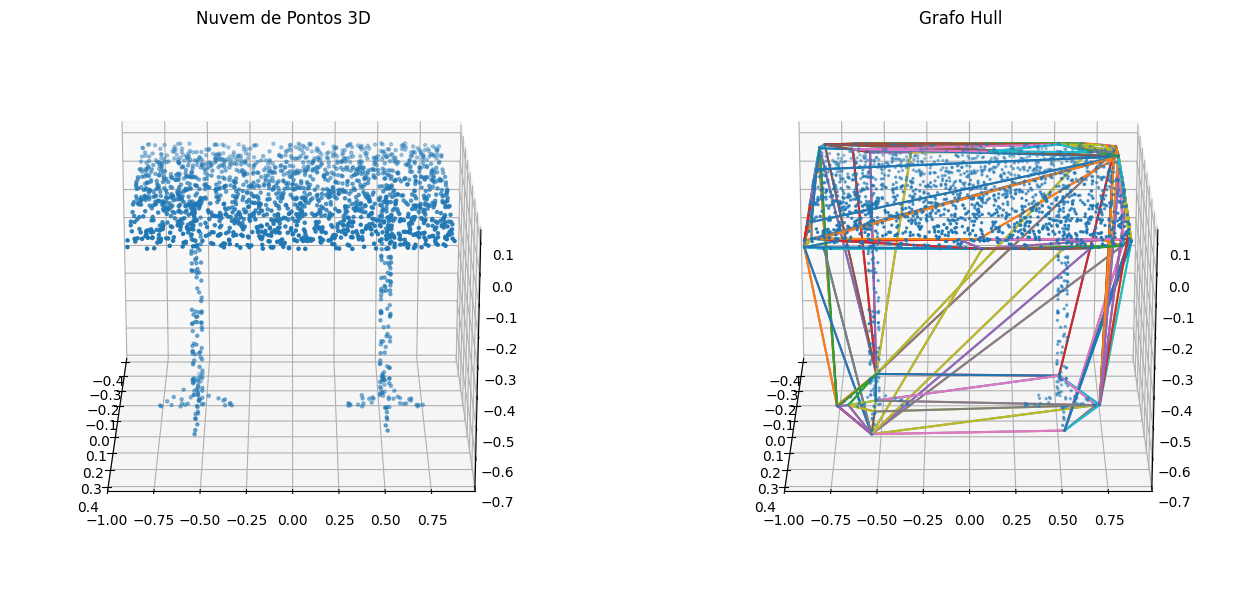

bed


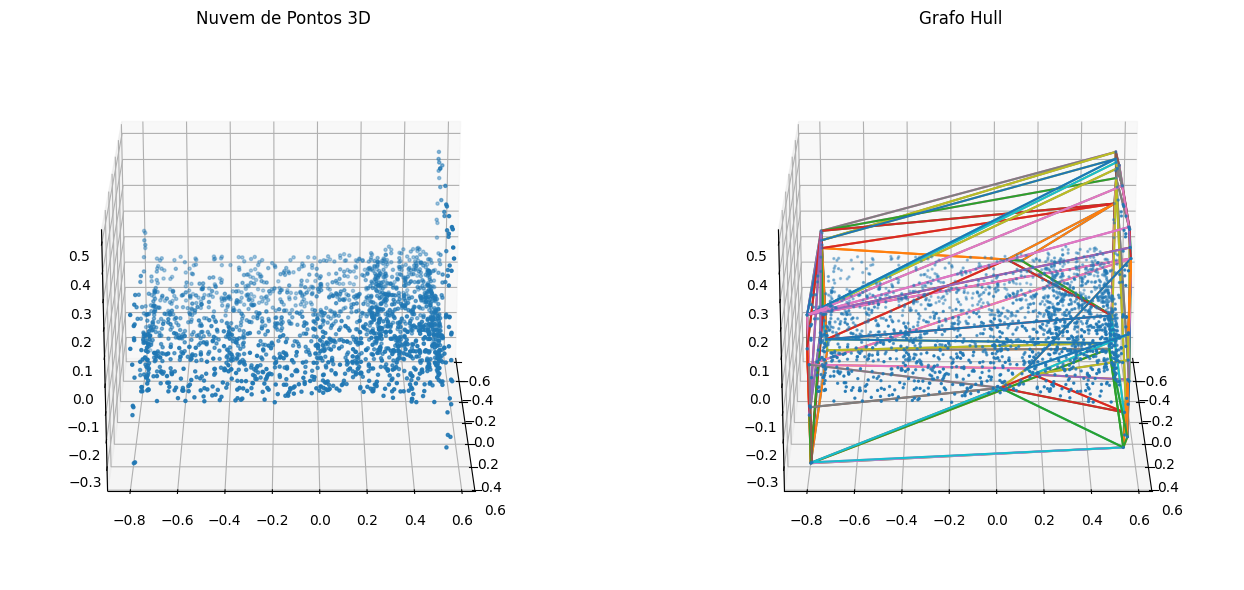

In [ ]:
print(minhas_categorias[y[10348]])
plotFigs(X[10348], z[10348], 0, 360)

print(minhas_categorias[y[0]])
plotFigs(X[0], z[0], 80)

print(minhas_categorias[y[2504]])
plotFigs(X[2504], z[2504], 20, 360)

print(minhas_categorias[y[6060]])
plotFigs(X[6060], z[6060], 20, 360)

print(minhas_categorias[y[7628]])
plotFigs(X[7628], z[7628], 20, 360)




In [ ]:
def extract_hull_morphology(points):
    hull = ConvexHull(points)

    vol = hull.volume
    area = hull.area

    return np.array([vol, area])

In [ ]:
def extract_hull_curvature(points, hull):
    mesh = trimesh.Trimesh(vertices=points, faces=hull.simplices)

    gauss = trimesh.curvature.discrete_gaussian_curvature_measure(mesh, mesh.vertices, 0.1)
    mean = trimesh.curvature.discrete_mean_curvature_measure(mesh, mesh.vertices, 0.1)

    return np.array([np.mean(gauss), np.std(gauss), np.mean(mean), np.std(mean)])

In [ ]:
def pipeline_extrator(points, hull):

    morph = extract_hull_morphology(points) # [vol, area]
    curv = extract_hull_curvature(points, hull) # [mean_gauss, std_gauss, mean_mean, std_mean]

    hull_pts = points[hull.vertices]
    dims = np.max(hull_pts, axis=0) - np.min(hull_pts, axis=0)

    return np.concatenate([morph, curv, dims])

In [ ]:
X_features = np.array([pipeline_extrator(pts, h) for pts, h in zip(X, z)])

In [ ]:
X_train, X_test, y_train, y_test, indices_treino, indices_teste = train_test_split(
     X_features, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Treinando SVM...")
svm = SVC(kernel='rbf', C=10.0, gamma='scale')
svm.fit(X_train, y_train)


print("Treinando RNA...")

rna = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000,
                    activation='relu', solver='adam', random_state=42)
rna.fit(X_train, y_train)

Treinando SVM...
Treinando RNA...


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)

In [ ]:
def avaliar(modelo, nome):
    y_pred = modelo.predict(X_test)
    acc = modelo.score(X_test, y_test)
    print(f"\n--- Resultado {nome} (Acurácia: {acc:.2%}) ---")
    print(classification_report(y_test, y_pred, target_names=minhas_categorias))

In [ ]:
avaliar(svm, "SVM")
avaliar(rna, "RNA")


--- Resultado SVM (Acurácia: 89.12%) ---
              precision    recall  f1-score   support

    airplane       1.00      1.00      1.00       501
       chair       0.94      0.98      0.96       711
       table       0.78      0.70      0.74       314
         bed       0.83      0.75      0.79       412
        sofa       0.82      0.89      0.86       544

    accuracy                           0.89      2482
   macro avg       0.88      0.86      0.87      2482
weighted avg       0.89      0.89      0.89      2482


--- Resultado RNA (Acurácia: 88.68%) ---
              precision    recall  f1-score   support

    airplane       1.00      1.00      1.00       501
       chair       0.96      0.98      0.97       711
       table       0.74      0.71      0.73       314
         bed       0.79      0.78      0.79       412
        sofa       0.84      0.84      0.84       544

    accuracy                           0.89      2482
   macro avg       0.87      0.86      0.86    

--- Teste Aleatório por Categoria ---

Categoria Real: AIRPLANE
Predição SVM: airplane (Correto)
Predição RNA: airplane (Correto)


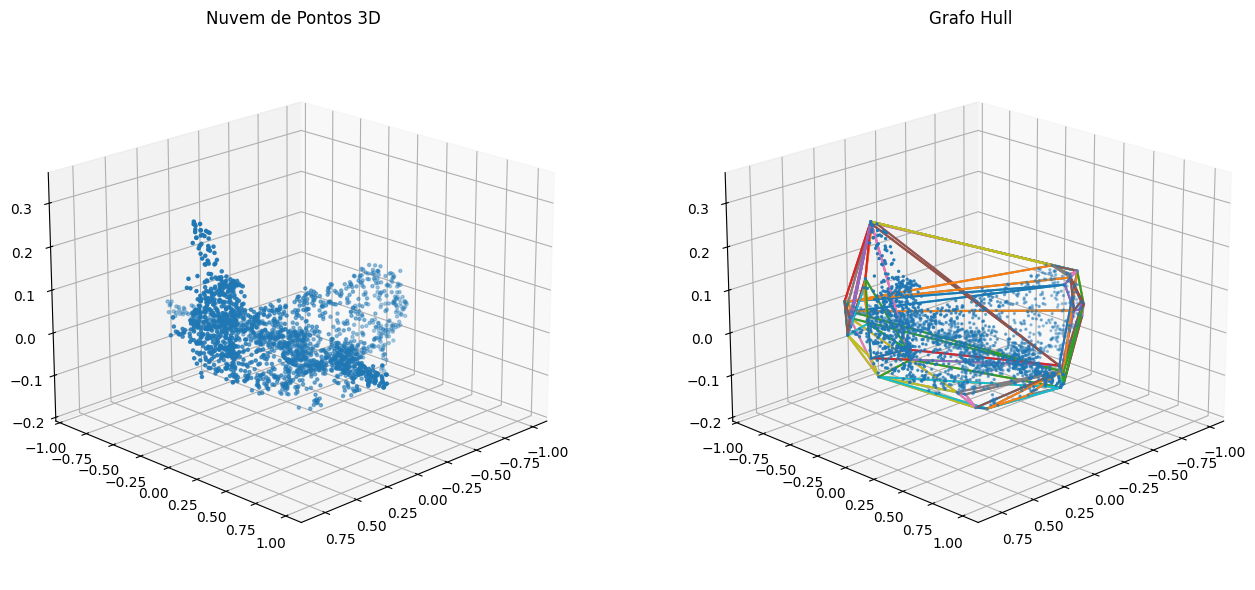

------------------------------

Categoria Real: CHAIR
Predição SVM: chair (Correto)
Predição RNA: chair (Correto)


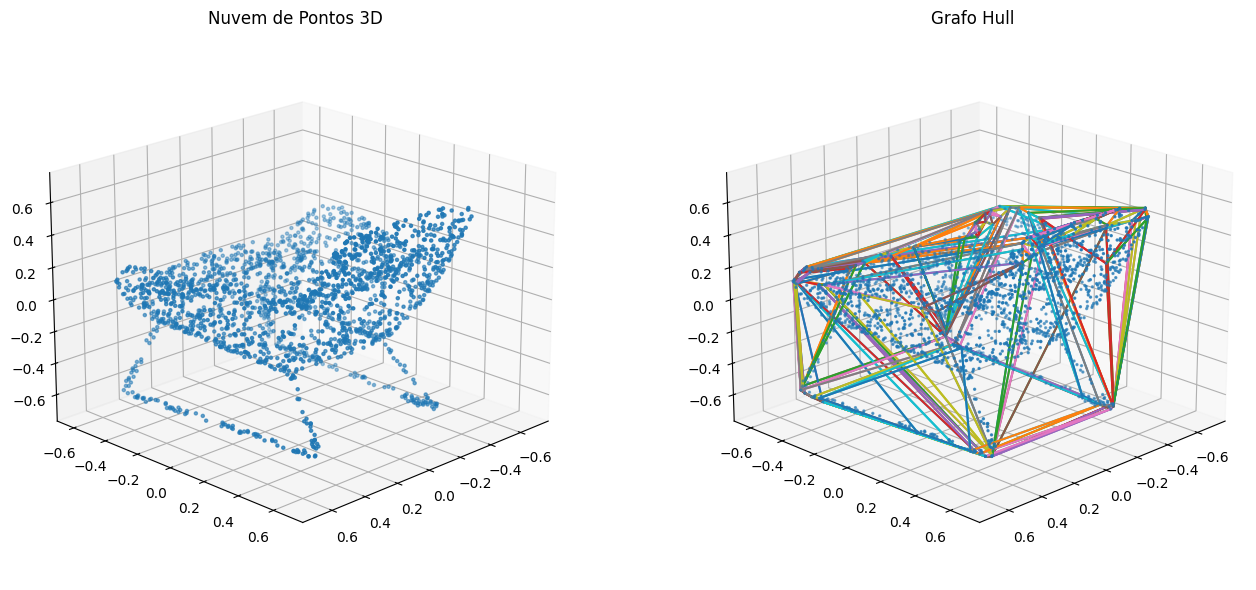

------------------------------

Categoria Real: TABLE
Predição SVM: table (Correto)
Predição RNA: table (Correto)


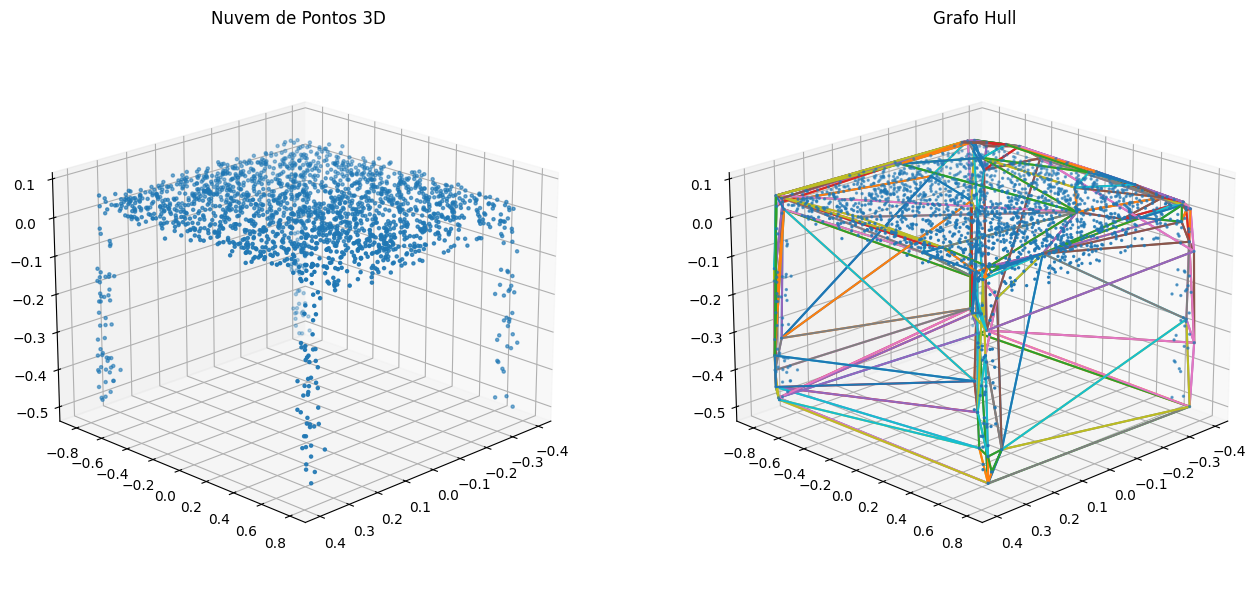

------------------------------

Categoria Real: BED
Predição SVM: bed (Correto)
Predição RNA: bed (Correto)


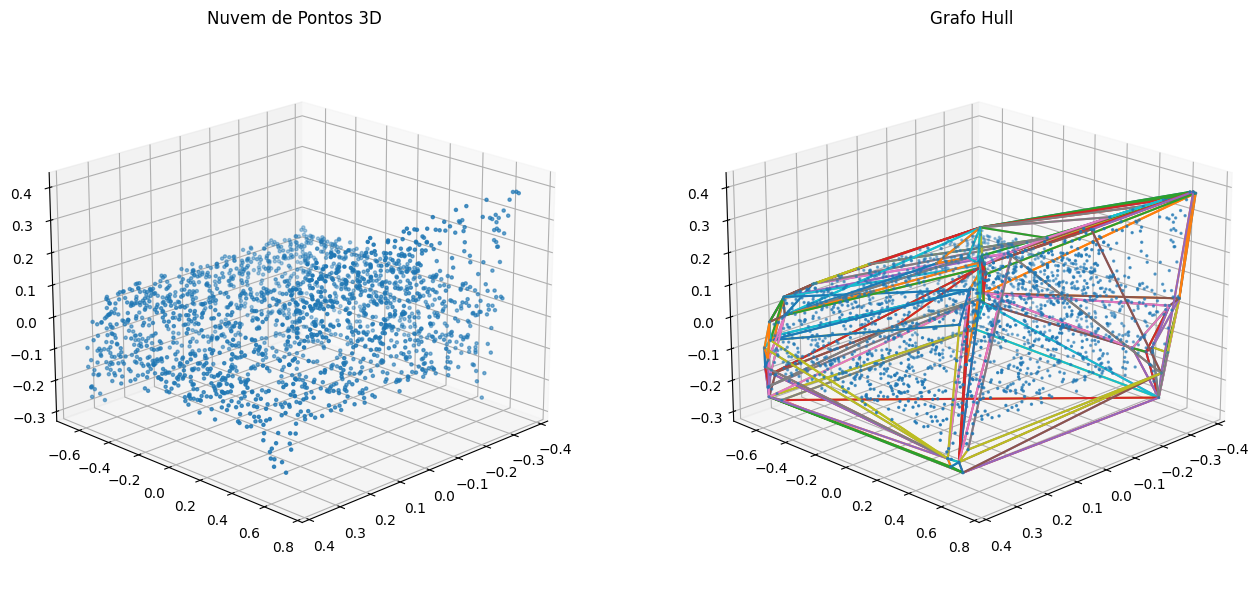

------------------------------

Categoria Real: SOFA
Predição SVM: sofa (Correto)
Predição RNA: sofa (Correto)


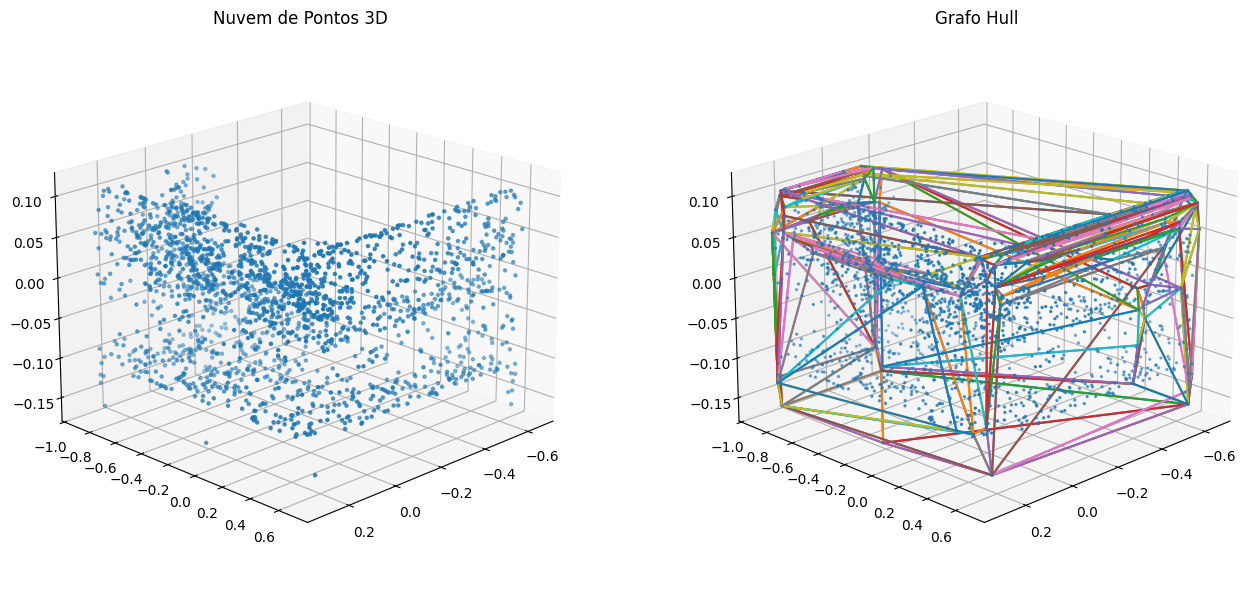

------------------------------


In [ ]:

print("--- Teste Aleatório por Categoria ---")

for i, cat_nome in enumerate(minhas_categorias):
    indices_da_cat = [idx for idx in indices_teste if y[idx] == i]

    if len(indices_da_cat) == 0:
        continue

    idx_escolhido = random.choice(indices_da_cat)

    feat_original = X_features[idx_escolhido].reshape(1, -1)
    feat_scaled = scaler.transform(feat_original)

    pred_svm = svm.predict(feat_scaled)[0]
    pred_rna = rna.predict(feat_scaled)[0]

    print(f"\nCategoria Real: {cat_nome.upper()}")
    print(f"Predição SVM: {minhas_categorias[pred_svm]} {'(Correto)' if pred_svm == i else '(Errado)'}")
    print(f"Predição RNA: {minhas_categorias[pred_rna]} {'(Correto)' if pred_rna == i else '(Errado)'}")


    plotFigs(X[idx_escolhido], z[idx_escolhido], elev=20, azim=45)

    print("-" * 30)